In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r'./credit_risk_dataset.csv')

In [2]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
df.shape

(32581, 12)

In [6]:
df['loan_status'].value_counts()

0    25473
1     7108
Name: loan_status, dtype: int64

In [7]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_age                       0
person_income                    0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
for col in df.columns:
    print(col, ":", df[col].nunique())
    

person_age : 58
person_income : 4295
person_home_ownership : 4
person_emp_length : 36
loan_intent : 6
loan_grade : 7
loan_amnt : 753
loan_int_rate : 348
loan_status : 2
loan_percent_income : 77
cb_person_default_on_file : 2
cb_person_cred_hist_length : 29


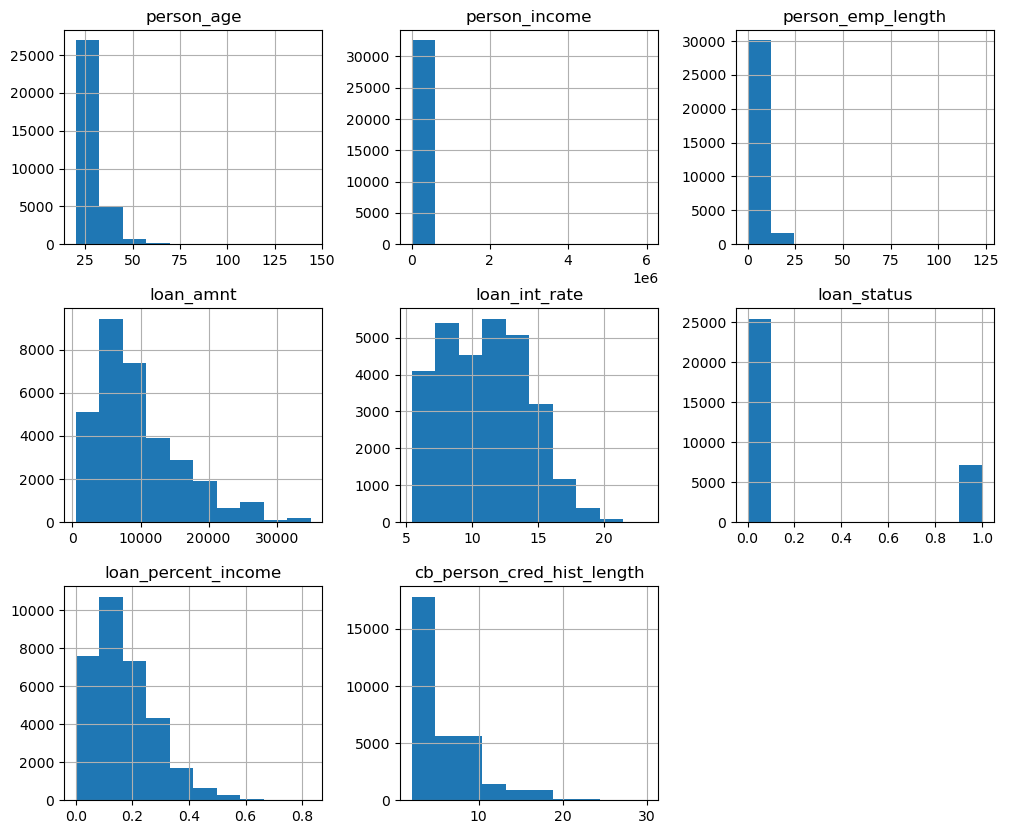

In [9]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

1. Person_age: most values are between 20-35
               few extreme values 
               values like 144 are unrealistic age
2. Person_income: Highly right-skewed
                  few earn extreme values(millions)
                  here outliers distort model
                  apply log transformation 
3. Person_emp_length: most values are between 0-10 years 
                      few extreme values like 100+ years are                             unrealistic so remove them
4. loan_amount: moderate right skew
                most loans are 5k-15k
                ** Larger loans might increase default risk fix it                  in feature engineering
5. loan_int_rate: normal distribution
                  missing values found, fix it 
                  ** Higher intrest = higher risk customers
6. loan_percent_income: few very high ratio
                        mostly values are low(0.3)
               Insight: higher ratio= financial stress set 
                        as strong predictor of default
7. cb-person_cred_hist_length: mostly short history
                      Insight: longer history= more trustworthy
8. loan_status: it is the target variable
                it is imbalanced 
                model bias toward 0
                      

In [10]:
df = df[df['person_age'] < 80]

In [11]:
df['person_income'] = np.log1p(df['person_income'])

In [16]:
df = df[df['person_emp_length'] < 30]

Handling Missing values

In [13]:
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

In [14]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

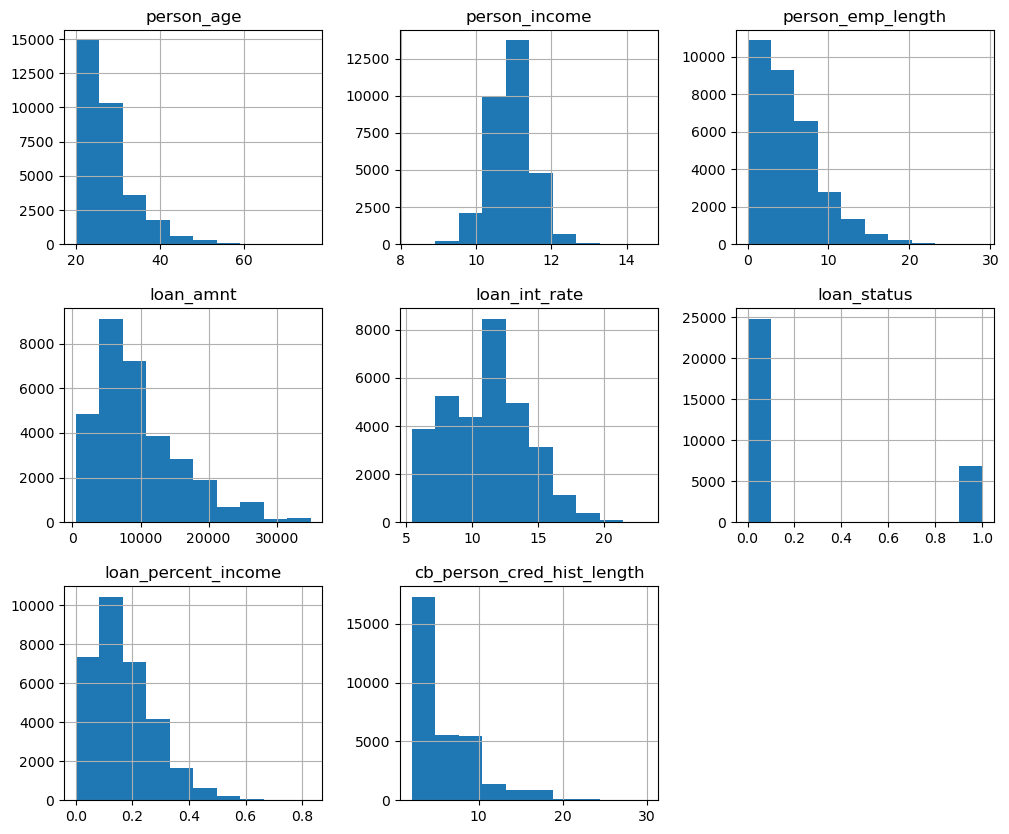

In [17]:
df.hist(figsize=(12,10))
plt.show()

loan_to_income feature directly gives information wheather this person can afford the loan or not

In [19]:
df['loan_to_income'] = df['loan_amnt'] / df['person_income']
df['loan_to_income']

1         109.055743
2         599.806587
3        3156.047422
4        3209.790686
5         271.727581
            ...     
32576     533.183010
32577    1507.021392
32578    3114.294120
32579    1258.558487
32580     608.241153
Name: loan_to_income, Length: 31667, dtype: float64

In [21]:
# Checks weather the person is overpaid or underpaid
df['income_per_year_exp'] = df['person_income'] / (df['person_emp_length'] + 1)
df['income_per_year_exp']

1        1.528270
2        4.584811
3        2.217964
4        1.211571
5        3.066797
           ...   
32576    5.439033
32577    2.339051
32578    2.809625
32579    1.986400
32580    3.548483
Name: income_per_year_exp, Length: 31667, dtype: float64

In [22]:
df['credit_per_age'] = df['cb_person_cred_hist_length'] / df['person_age']
df['credit_per_age']

1        0.095238
2        0.120000
3        0.086957
4        0.166667
5        0.095238
           ...   
32576    0.526316
32577    0.351852
32578    0.430769
32579    0.464286
32580    0.454545
Name: credit_per_age, Length: 31667, dtype: float64

In [23]:
df['high_risk_flag'] = (df['loan_percent_income'] > 0.4).astype(int)
df['high_risk_flag']

1        0
2        1
3        1
4        1
5        0
        ..
32576    0
32577    0
32578    1
32579    0
32580    0
Name: high_risk_flag, Length: 31667, dtype: int32

In [24]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income,income_per_year_exp,credit_per_age,high_risk_flag
1,21,9.169623,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,109.055743,1.528270,0.095238,0
2,25,9.169623,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,599.806587,4.584811,0.120000,1
3,23,11.089821,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,3156.047422,2.217964,0.086957,1
4,24,10.904138,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,3209.790686,1.211571,0.166667,1
5,21,9.200391,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,271.727581,3.066797,0.095238,0
